<a href="https://colab.research.google.com/github/rachakondasaivarshini/GAN-PROGRAMS/blob/main/gan_exp_2_postlab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9054 - loss: 0.3295 - val_accuracy: 0.9553 - val_loss: 0.1567
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9536 - loss: 0.1617 - val_accuracy: 0.9678 - val_loss: 0.1130
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9636 - loss: 0.1212 - val_accuracy: 0.9709 - val_loss: 0.1003
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9703 - loss: 0.0978 - val_accuracy: 0.9718 - val_loss: 0.0977
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9739 - loss: 0.0832 - val_accuracy: 0.9741 - val_loss: 0.0813
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9317 - loss: 0.2386 - val_accuracy: 0.9715 - val_loss: 0.1058
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.9735 - loss: 0.0901 - val_accuracy: 0.9766 - val_loss: 0.0805
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9813 - loss: 0.0664 - va

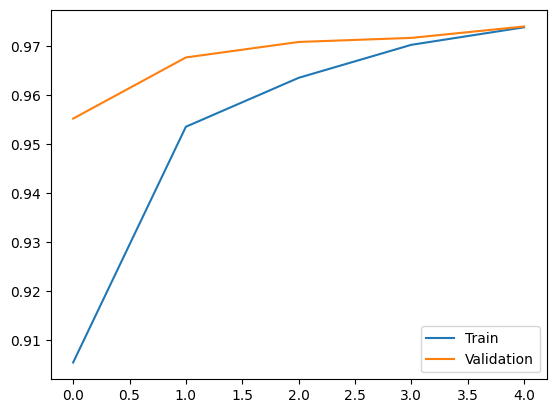

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

# Load and normalize data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# DNN Model
dnn = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

dnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

history = dnn.fit(X_train, y_train,
                  epochs=5, validation_split=0.2)

# CNN Model
X_train = X_train[..., None]
X_test = X_test[..., None]

cnn = Sequential([
    Conv2D(32, 3, activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(),
    Flatten(),
    Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.fit(X_train, y_train, epochs=5, validation_split=0.2)

print("DNN Accuracy:", dnn.evaluate(X_test[..., 0], y_test, verbose=0)[1])
print("CNN Accuracy:", cnn.evaluate(X_test, y_test, verbose=0)[1])

# Plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.show()